[TEMPatchDataset] 2269 patches from 11 images


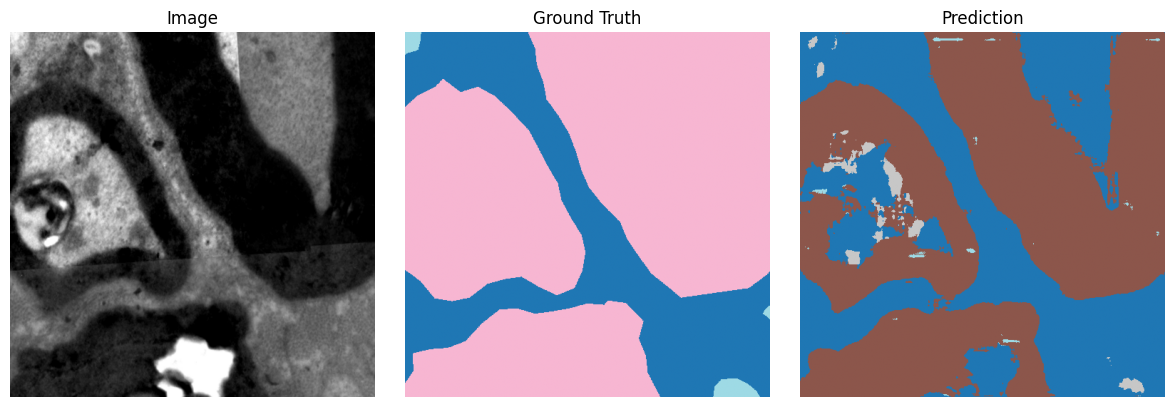

In [3]:
import torch
import matplotlib.pyplot as plt

from src.datasets.tem_dataset import TEMPatchDataset
from src.models.unet_small import UNetSmall

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load dataset (same settings as training)
h5_path = "/home/minq02/github/TEMCellSegmentation/data/train/train_data.h5"
patch_size = 512

ds = TEMPatchDataset(h5_path, patch_size=patch_size, stride=patch_size)

# 2. Load model weights
model = UNetSmall(in_ch=1, n_classes=5).to(device)
model.load_state_dict(torch.load("tem_unet_small.pth", map_location=device))
model.eval()

# 3. Take one patch and run inference
img, mask = ds[1204]                      # img, mask: (H, W)
x = img.unsqueeze(0).unsqueeze(0).to(device)  # (1,1,H,W)

with torch.no_grad():
    logits = model(x)                  # (1,5,H,W)
    pred = logits.argmax(1).squeeze(0).cpu()  # (H,W) predicted labels

# 4. Plot original image, GT mask, prediction
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(img.numpy(), cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(mask.numpy(), cmap="tab20")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Prediction")
plt.imshow(pred.numpy(), cmap="tab20")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import json
import matplotlib.pyplot as plt

with open("loss_history.json", "r") as f:
    hist = json.load(f)

train_losses = hist["train_losses"]
val_losses = hist["val_losses"]

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning curve (CE + Dice)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()